# PART 1 - The Bayesian Perspective
##Is there a statistically significant difference in the BMI between individuals who have ever been told they had a heart attack and those who have not?


##1- Data Setup & Sub-sampling

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

df = pd.read_csv('/content/random_5k_rows.csv')
heart_attack_col = 'CVDINFR4'
cols = ['_BMI5', heart_attack_col]
df_clean = df[cols].copy().dropna()
df_clean['_BMI5'] = df_clean['_BMI5'] / 100.0
df_clean = df_clean[df_clean[heart_attack_col].isin([1, 2])]
df_clean['Y'] = df_clean[heart_attack_col].apply(lambda x: 1 if x == 1 else 0)
df_clean['X'] = df_clean['_BMI5']

np.random.seed(42)

indices = df_clean.index.tolist()
np.random.shuffle(indices)

idx_observed = indices[:200]
idx_past = indices[200:1200]

df_observed = df_clean.loc[idx_observed].copy()
df_past = df_clean.loc[idx_past].copy()

print(f"Observed Data Size: {len(df_observed)}")
print(f"Past Data Size: {len(df_past)}")
print("Data preparation complete.")

Observed Data Size: 200
Past Data Size: 1000
Data preparation complete.


##2A- Bootstrap Confidence Interval

In [ ]:
tau = df_observed['X'].median()
print(f"Threshold tau (Median BMI): {tau}")
df_observed['Z'] = (df_observed['X'] > tau).astype(int)

def calc_psi(data):
    p1 = data[data['Y'] == 1]['Z'].mean()
    p2 = data[data['Y'] == 0]['Z'].mean()
    epsilon = 1e-5
    p1 = np.clip(p1, epsilon, 1 - epsilon)
    p2 = np.clip(p2, epsilon, 1 - epsilon)

    # Logit function: eta(p) = log(p / (1-p))
    eta_p1 = np.log(p1 / (1 - p1))
    eta_p2 = np.log(p2 / (1 - p2))

    # Psi = eta(p1) - eta(p2)
    psi = eta_p1 - eta_p2
    return psi, p1, p2

psi_hat, p1_hat, p2_hat = calc_psi(df_observed)

#Bootstrap
n_boot = 10000
boot_psis = []

np.random.seed(42)
for _ in range(n_boot):
    sample = df_observed.sample(n=len(df_observed), replace=True)
    psi_b, _, _ = calc_psi(sample)
    boot_psis.append(psi_b)

# Calculate CI
alpha = 0.05
ci_lower = np.percentile(boot_psis, (alpha/2) * 100)
ci_upper = np.percentile(boot_psis, (1 - alpha/2) * 100)

print(f"Part 2a (Bootstrap):")
print(f"Estimated Psi: {psi_hat:.4f}")
print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")

Threshold tau (Median BMI): 28.125
Part 2a (Bootstrap):
Estimated Psi: -0.3092
95% CI: [-1.6513, 0.8643]


##2B- Bayesian Estimation with Uniform Prior

In [ ]:

#Get Counts from Observed Data
#Group 1 (Y=1): Heart Attack
n1 = len(df_observed[df_observed['Y'] == 1])
z1 = df_observed[df_observed['Y'] == 1]['Z'].sum() # Successes (Z=1)

# Group 2 (Y=0): No Heart Attack
n2 = len(df_observed[df_observed['Y'] == 0])
z2 = df_observed[df_observed['Y'] == 0]['Z'].sum() # Successes (Z=1)

print(f"Group 1 (Heart Attack): n={n1}, Z=1 count={z1}")
print(f"Group 2 (No Heart Attack): n={n2}, Z=1 count={z2}")

#Simulation with Uniform Prior Beta(1, 1)
n_sim = 10000
np.random.seed(42)

# Posterior parameters: alpha = prior_alpha + successes, beta = prior_beta + failures
# Uniform Prior: alpha=1, beta=1
post_p1 = np.random.beta(1 + z1, 1 + (n1 - z1), n_sim)
post_p2 = np.random.beta(1 + z2, 1 + (n2 - z2), n_sim)

# Calculate Psi for all simulations
psi_sim = np.log(post_p1 / (1 - post_p1)) - np.log(post_p2 / (1 - post_p2))
psi_est_unif = np.mean(psi_sim)
ci_lower_unif = np.percentile(psi_sim, 2.5)
ci_upper_unif = np.percentile(psi_sim, 97.5)

print(f"Part 2b (Uniform Prior):")
print(f"Estimated Psi (Posterior Mean): {psi_est_unif:.4f}")
print(f"95% Credible Interval: [{ci_lower_unif:.4f}, {ci_upper_unif:.4f}]")

Group 1 (Heart Attack): n=14, Z=1 count=6
Group 2 (No Heart Attack): n=186, Z=1 count=94
Part 2b (Uniform Prior):
Estimated Psi (Posterior Mean): -0.3019
95% Credible Interval: [-1.3801, 0.7264]


##2C- Bayesian Estimation with Jeffreys Prior

In [ ]:

#Simulation with Jeffreys Prior Beta(0.5, 0.5)
n_sim = 10000
np.random.seed(42)

# Posterior parameters: alpha = 0.5 + z, beta = 0.5 + (n - z)
post_p1_jeff = np.random.beta(0.5 + z1, 0.5 + (n1 - z1), n_sim)
post_p2_jeff = np.random.beta(0.5 + z2, 0.5 + (n2 - z2), n_sim)

# Calculate Psi
psi_sim_jeff = np.log(post_p1_jeff / (1 - post_p1_jeff)) - np.log(post_p2_jeff / (1 - post_p2_jeff))
psi_est_jeff = np.mean(psi_sim_jeff)
ci_lower_jeff = np.percentile(psi_sim_jeff, 2.5)
ci_upper_jeff = np.percentile(psi_sim_jeff, 97.5)

print(f"Part 2c (Jeffreys Prior):")
print(f"Estimated Psi (Posterior Mean): {psi_est_jeff:.4f}")
print(f"95% Credible Interval: [{ci_lower_jeff:.4f}, {ci_upper_jeff:.4f}]")

Part 2c (Jeffreys Prior):
Estimated Psi (Posterior Mean): -0.3211
95% Credible Interval: [-1.4553, 0.7293]


##2D- Bayesian Estimation with Historical Prior

In [ ]:
#Process Past Data to get Prior Parameters
df_past['Z'] = (df_past['X'] > tau).astype(int)

n1_past = len(df_past[df_past['Y'] == 1])
z1_past = df_past[df_past['Y'] == 1]['Z'].sum()

n2_past = len(df_past[df_past['Y'] == 0])
z2_past = df_past[df_past['Y'] == 0]['Z'].sum()

print(f"Past Data - Group 1: n={n1_past}, successes={z1_past}")
print(f"Past Data - Group 2: n={n2_past}, successes={z2_past}")
alpha1_prior = z1_past if z1_past > 0 else 1
beta1_prior = (n1_past - z1_past) if (n1_past - z1_past) > 0 else 1

alpha2_prior = z2_past if z2_past > 0 else 1
beta2_prior = (n2_past - z2_past) if (n2_past - z2_past) > 0 else 1

#Simulation with Historical Prior
n_sim = 10000
np.random.seed(42)

# Posterior: alpha = prior_alpha + current_successes
post_p1_past = np.random.beta(alpha1_prior + z1, beta1_prior + (n1 - z1), n_sim)
post_p2_past = np.random.beta(alpha2_prior + z2, beta2_prior + (n2 - z2), n_sim)

# Calculate Psi
psi_sim_past = np.log(post_p1_past / (1 - post_p1_past)) - np.log(post_p2_past / (1 - post_p2_past))

psi_est_past = np.mean(psi_sim_past)
ci_lower_past = np.percentile(psi_sim_past, 2.5)
ci_upper_past = np.percentile(psi_sim_past, 97.5)

print(f"Part 2d (Historical Prior):")
print(f"Estimated Psi (Posterior Mean): {psi_est_past:.4f}")
print(f"95% Credible Interval: [{ci_lower_past:.4f}, {ci_upper_past:.4f}]")

Past Data - Group 1: n=70, successes=37
Past Data - Group 2: n=930, successes=479
Part 2d (Historical Prior):
Estimated Psi (Posterior Mean): -0.0049
95% Credible Interval: [-0.4416, 0.4323]


##2E- Comparison of All Estimators

In [ ]:
results = pd.DataFrame({
    'Method': ['Bootstrap (Frequentist)', 'Uniform Prior', 'Jeffreys Prior', 'Historical Prior'],
    'Estimate (Psi)': [psi_hat, psi_est_unif, psi_est_jeff, psi_est_past],
    'CI Lower': [ci_lower, ci_lower_unif, ci_lower_jeff, ci_lower_past],
    'CI Upper': [ci_upper, ci_upper_unif, ci_upper_jeff, ci_upper_past]
})

print("Comparison of Estimators for Psi (Log Odds Ratio):")
print(results)

Comparison of Estimators for Psi (Log Odds Ratio):
                    Method  Estimate (Psi)  CI Lower  CI Upper
0  Bootstrap (Frequentist)       -0.309188 -1.651259  0.864295
1            Uniform Prior       -0.301950 -1.380074  0.726399
2           Jeffreys Prior       -0.321063 -1.455307  0.729289
3         Historical Prior       -0.004871 -0.441603  0.432288


##Conclusion:
Is there a statistically significant difference in the BMI between individuals who have ever been told they had a heart attack and those who have not?

**No**, based on this analysis, there is no statistically significant difference in BMI between the two groups. All four statistical methods produced confidence intervals that include zero, meaning we cannot rule out the possibility that there is no difference at all. While the Bootstrap and simple Bayesian priors yielded wide, uncertain ranges due to the small sample size ($N=200$), the Historical Prior used the larger past dataset ($N=1000$) to refine the result. This method produced the most precise estimate with the narrowest range, strongly suggesting that the true difference is very close to zero.

#**PART 2**

We study a linear regression model with **BMI** as the continuous response variable $Y$, and explanatory variables $X_1$ = age (ordinal), $X_2$ = annual income (ordinal), and $X_3$ = smoking status (binary).
We compare different methods for handling missing values in $Y$ by artificially introducing missingness and evaluating the resulting estimators.






###**Q1**

In [8]:
import pandas as pd

df = pd.read_csv("random_5k_rows.csv")

# Create a separate dataset for linear regression
lr_data = df[["_BMI5", "_AGE80", "INCOME3", "_RFSMOK3"]].rename(columns={
    "_BMI5": "BMI",
    "_AGE80": "age",
    "INCOME3": "income",
    "_RFSMOK3": "smoker"
})

# Keep only rows with no missing values
lr_data = lr_data.dropna()

# Randomly sample 1000 observations
lr_data = lr_data.sample(n=1000, random_state=42)
lr_data.reset_index(drop=True, inplace=True)

lr_data.head()


,BMI,age,income,smoker
0,2006.0,80.0,7.0,1.0
1,2231.0,53.0,8.0,1.0
2,5081.0,50.0,7.0,1.0
3,2362.0,76.0,7.0,1.0
4,2921.0,71.0,3.0,2.0


###**Q2**

Define the linear regression model like that:
$$
Y_i = \beta_0 + \beta_1 X_{1i} + \beta_2 X_{2i} + \beta_3 X_{3i} + \varepsilon_i,
$$
where $X_1$ denotes age, $X_2$ denotes annual income, $X_3$ denotes smoking status, and $\varepsilon_i$ is an error term with mean zero and constant variance.

In [16]:
import statsmodels.api as sm
import numpy as np

# Define response and explanatory variables
Y = lr_data["BMI"]
X = lr_data[["age", "income", "smoker"]]

# Add intercept
X = sm.add_constant(X)

# Fit linear regression
model = sm.OLS(Y, X).fit()

# Extract estimates
beta_hat = model.params
cov_matrix = model.cov_params()

std_errors = pd.Series(
    np.sqrt(np.diag(cov_matrix)),
    index=beta_hat.index
)

ci_lower = beta_hat - 1.96 * std_errors
ci_upper = beta_hat + 1.96 * std_errors

# Create results table FIRST
results = pd.DataFrame({
    "Coefficient": beta_hat,
    "Std. Error": std_errors,
    "CI 95% Lower": ci_lower,
    "CI 95% Upper": ci_upper
})

# Rename index ONCE
results.index = [
    "const (beta_hat_0)",
    "age (beta_hat_1)",
    "income (beta_hat_2)",
    "smoker (beta_hat_3)"
]

results


,Coefficient,Std. Error,CI 95% Lower,CI 95% Upper
const (beta_hat_0),3274.914084,142.665163,2995.290363,3554.537804
age (beta_hat_1),0.269708,1.421085,-2.515617,3.055034
income (beta_hat_2),-33.664731,9.863323,-52.996844,-14.332619
smoker (beta_hat_3),-106.377063,65.205077,-234.179015,21.424888


**Results**

**Point Estimates**
- const ($\hat\beta_0$) = 3274.914084  
- age ($\hat\beta_1$) = 0.269708  
- income ($\hat\beta_2$) = -33.664731  
- smoker ($\hat\beta_3$) = -106.377063  

**95% Confidence Intervals**
- const ($\hat\beta_0$): [2995.290363, 3554.537804]  
- age ($\hat\beta_1$): [-2.515617, 3.055034]  
- income ($\hat\beta_2$): [-52.996844, -14.332619]  
- smoker ($\hat\beta_3$): [-234.179015, 21.424888]  


###**Q3**

In [17]:
np.random.seed(42)

# Copy data
lr_data_missing = lr_data.copy()

# Sort indices by Y (BMI)
sorted_idx = lr_data_missing["BMI"].sort_values().index
n = len(sorted_idx)  # should be 1000

# Increasing probabilities from 1/5 to 4/5
p = np.linspace(1/5, 4/5, n)

# Draw Bernoulli variables
u = np.random.rand(n)
scores = u < p   # initial deletion tendency

# If more than 500 marked, keep only the 500 strongest (highest p)
if scores.sum() > 500:
    candidates = np.where(scores)[0]
    keep = candidates[np.argsort(p[candidates])[-500:]]
    delete_positions = keep

# If fewer than 500 marked, add highest-p observations
elif scores.sum() < 500:
    candidates = np.where(~scores)[0]
    add = candidates[np.argsort(p[candidates])[-(500 - scores.sum()):]]
    delete_positions = np.concatenate([np.where(scores)[0], add])

else:
    delete_positions = np.where(scores)[0]

# Map back to original indices
idx_to_delete = sorted_idx[delete_positions]

# Delete only Y values
lr_data_missing.loc[idx_to_delete, "BMI"] = np.nan

# Sanity check
lr_data_missing["BMI"].isna().sum()


np.int64(500)

###**Q4**

####**Section a**



In [18]:
# Complete-case data from dataset with missing values
analysis_data = lr_data_missing.dropna(subset=["BMI"]).copy()

# Define response and predictors
Y_cc = analysis_data["BMI"]
X_cc = analysis_data[["age", "income", "smoker"]]

# Add intercept
X_cc = sm.add_constant(X_cc)

# Fit linear regression
ols_cc_model = sm.OLS(Y_cc, X_cc).fit()

# Extract estimates
beta_cc = ols_cc_model.params
cov_cc = ols_cc_model.cov_params()

# Standard errors
se_cc = pd.Series(
    np.sqrt(np.diag(cov_cc)),
    index=beta_cc.index
)

# 95% confidence intervals
ciL_cc = beta_cc - 1.96 * se_cc
ciU_cc = beta_cc + 1.96 * se_cc

# Create results table
cc_results = pd.DataFrame({
    "Coefficient": beta_cc,
    "Std. Error": se_cc,
    "CI 95% Lower": ciL_cc,
    "CI 95% Upper": ciU_cc
})

# Rename index for clarity
cc_results.index = [
    "const (beta_hat_0)",
    "age (beta_hat_1)",
    "income (beta_hat_2)",
    "smoker (beta_hat_3)"
]

print("Number of complete observations:", len(analysis_data))
cc_results


Number of complete observations: 500


,Coefficient,Std. Error,CI 95% Lower,CI 95% Upper
const (beta_hat_0),2560.043437,167.718304,2231.315562,2888.771313
age (beta_hat_1),3.528089,1.597212,0.397554,6.658624
income (beta_hat_2),-18.228429,11.833243,-41.421585,4.964727
smoker (beta_hat_3),19.536210,76.397242,-130.202385,169.274804


**Results**

**CC Point Estimates**
- const ($\hat\beta_0$) = 2560.043437  
- age ($\hat\beta_1$) = 3.528089  
- income ($\hat\beta_2$) = -18.228429  
- smoker ($\hat\beta_3$) = 19.536210  

**CC 95% Confidence Intervals**
- const ($\hat\beta_0$): [2231.315562, 2888.771313]  
- age ($\hat\beta_1$): [0.397554, 6.658624]  
- income ($\hat\beta_2$): [-41.421585, 4.964727]  
- smoker ($\hat\beta_3$): [-130.202385, 169.274804]  


####**Section b**

Using regression imputation, missing values of $Y$ were replaced by predictions from a linear model fitted on the observed data.

In [20]:
# 1) Split data
observed_data = lr_data_missing.dropna(subset=["BMI"]).copy()
missing_data  = lr_data_missing[lr_data_missing["BMI"].isna()].copy()

# 2) Fit regression on observed data
Y_obs = observed_data["BMI"]
X_obs = observed_data[["age", "income", "smoker"]]
X_obs = sm.add_constant(X_obs)

imp_model = sm.OLS(Y_obs, X_obs).fit()

# 3) Predict missing Y values
X_miss = missing_data[["age", "income", "smoker"]]
X_miss = sm.add_constant(X_miss)

BMI_pred = imp_model.predict(X_miss)

# 4) Create imputed dataset
lr_data_imp = lr_data_missing.copy()
lr_data_imp.loc[lr_data_imp["BMI"].isna(), "BMI"] = BMI_pred

# 5) Run OLS on imputed data
Y_imp = lr_data_imp["BMI"]
X_imp = lr_data_imp[["age", "income", "smoker"]]
X_imp = sm.add_constant(X_imp)

imp_ols_model = sm.OLS(Y_imp, X_imp).fit()

# 6) Extract estimates and CI
beta_imp = imp_ols_model.params
cov_imp = imp_ols_model.cov_params()

se_imp = pd.Series(np.sqrt(np.diag(cov_imp)), index=beta_imp.index)
ciL_imp = beta_imp - 1.96 * se_imp
ciU_imp = beta_imp + 1.96 * se_imp

# Results table
imp_results = pd.DataFrame({
    "Coefficient": beta_imp,
    "Std. Error": se_imp,
    "CI 95% Lower": ciL_imp,
    "CI 95% Upper": ciU_imp
})

imp_results.index = [
    "const (beta_hat_0)",
    "age (beta_hat_1)",
    "income (beta_hat_2)",
    "smoker (beta_hat_3)"
]

imp_results


,Coefficient,Std. Error,CI 95% Lower,CI 95% Upper
const (beta_hat_0),2560.043437,83.783106,2395.828549,2724.258326
age (beta_hat_1),3.528089,0.834562,1.892348,5.163830
income (beta_hat_2),-18.228429,5.792443,-29.581617,-6.875241
smoker (beta_hat_3),19.536210,38.293048,-55.518164,94.590583


**Results**

**RI Point Estimates**
- const ($\hat\beta_0$) = 2560.043437  
- age ($\hat\beta_1$) = 3.528089  
- income ($\hat\beta_2$) = -18.228429  
- smoker ($\hat\beta_3$) = 19.536210  

**RI 95% Confidence Intervals**
- const ($\hat\beta_0$): [2395.828549, 2724.258326]  
- age ($\hat\beta_1$): [1.892348, 5.163830]  
- income ($\hat\beta_2$): [-29.581617, -6.875241]  
- smoker ($\hat\beta_3$): [-55.518164, 94.590583]  


**Results**

Regression imputation yields identical point estimates to the complete-case analysis (as expected), but substantially smaller standard errors and narrower confidence intervals.
This reflects the deterministic nature of regression imputation, which artificially reduces variability by treating imputed values as known (the missing values are filled in using a single predicted value from the regression model).


####**Section c**

Now we used multiple Imputation for complete the missing values of BMI column.

In [22]:
np.random.seed(42)

m = 10  # number of imputations

# Split observed / missing
obs_data = lr_data_missing.dropna(subset=["BMI"]).copy()
miss_data = lr_data_missing[lr_data_missing["BMI"].isna()].copy()

# Fit model on observed data
Y_obs = obs_data["BMI"]
X_obs = sm.add_constant(obs_data[["age", "income", "smoker"]])
mi_base_model = sm.OLS(Y_obs, X_obs).fit()

# Residual std (sigma) assuming normal errors
sigma_hat = np.sqrt(mi_base_model.mse_resid)

# Containers for results
beta_list = []
cov_list = []

for j in range(m):
    # Predict mean for missing
    X_miss = sm.add_constant(miss_data[["age", "income", "smoker"]])
    mu_pred = mi_base_model.predict(X_miss)

    # Add normal noise
    eps = np.random.normal(0, sigma_hat, size=len(mu_pred))
    Y_imputed = mu_pred + eps

    # Create completed dataset
    mi_data = lr_data_missing.copy()
    mi_data.loc[mi_data["BMI"].isna(), "BMI"] = Y_imputed

    # Fit OLS on completed data
    Y_mi = mi_data["BMI"]
    X_mi = sm.add_constant(mi_data[["age", "income", "smoker"]])
    mi_model = sm.OLS(Y_mi, X_mi).fit()

    beta_list.append(mi_model.params)
    cov_list.append(mi_model.cov_params())

# Stack results
beta_df = pd.DataFrame(beta_list)
beta_df.index = range(1, len(beta_df) + 1)
beta_df


,const,age,income,smoker
1,2688.645492,2.290674,-20.034385,-22.775749
2,2616.431426,3.444202,-11.764503,-51.823225
3,2642.004258,4.046976,-17.510037,-48.663196
4,2521.865471,3.660633,-11.581298,18.323081
5,2548.531251,3.280834,-17.272120,32.091652
6,2530.893345,2.502170,-13.310071,69.357050
7,2485.194345,3.613102,-13.840270,50.388323
8,2659.781301,2.124632,-28.381963,48.317278
9,2402.231671,4.109907,-7.937596,46.289427
10,2408.687324,3.909729,-6.280743,64.353286


**Results**

We can see that here each completed dataset is slightly different, and the variability across estimates reflects the uncertainty about the missing values.
Thats because in multiple imputation we assume a normal error distribution and sample a different value around the prediction each time, rather than copying the same value.





####**Section d**

In [23]:
M = len(beta_df)  # number of imputations

# 1) Pooled point estimates (beta_MI)
beta_MI = beta_df.mean()

# 2) Within-imputation variance (W)
# average of variances from each regression
W = sum([np.diag(cov) for cov in cov_list]) / M
W = pd.Series(W, index=beta_MI.index)

# 3) Between-imputation variance (B)
B = ((beta_df - beta_MI) ** 2).sum() / (M - 1)

# 4) Total variance (Rubin's formula)
T = W + (1 + 1/M) * B

# Standard errors
se_MI = np.sqrt(T)

# 95% confidence intervals
ciL_MI = beta_MI - 1.96 * se_MI
ciU_MI = beta_MI + 1.96 * se_MI

# Final results table
mi_results = pd.DataFrame({
    "Coefficient": beta_MI,
    "Std. Error": se_MI,
    "CI 95% Lower": ciL_MI,
    "CI 95% Upper": ciU_MI
})

# Nice index names
mi_results.index = [
    "const (beta_hat_0)",
    "age (beta_hat_1)",
    "income (beta_hat_2)",
    "smoker (beta_hat_3)"
]

mi_results


,Coefficient,Std. Error,CI 95% Lower,CI 95% Upper
const (beta_hat_0),2550.426588,158.655695,2239.461425,2861.391751
age (beta_hat_1),3.298286,1.409119,0.536412,6.060160
income (beta_hat_2),-14.791299,10.578862,-35.525868,5.943271
smoker (beta_hat_3),20.585793,72.170050,-120.867506,162.039092


**Results**

**MI Point Estimates**
- const ($\hat\beta_0$) = 2550.426588  
- age ($\hat\beta_1$) = 3.298286  
- income ($\hat\beta_2$) = -14.791299  
- smoker ($\hat\beta_3$) = 20.585793  

**MI 95% Confidence Intervals**
- const ($\hat\beta_0$): [2239.461425, 2861.391751]  
- age ($\hat\beta_1$): [0.536412, 6.060160]  
- income ($\hat\beta_2$): [-35.525868, 5.943271]  
- smoker ($\hat\beta_3$): [-120.867506, 162.039092]  


####**Section e**

We model the probability that the response variable is observed using a logistic regression model.
Let $R=\mathbb{1}\{Y \text{ is observed}\}$, $X=(1,X_1,\ldots,X_k)^\top$ denote the vector of explanatory variables (including an intercept), and $\beta=(\beta_0,\beta_1,\ldots,\beta_k)^\top$.
The model is given by,
$$
P(R=1 \mid X) = \frac{\exp(X^\top \beta)}{1+\exp(X^\top \beta)}.
$$





In [24]:
# 1) Define response R: 1 if Y observed, 0 if missing
lr_data_missing["R"] = lr_data_missing["BMI"].notna().astype(int)

# 2) Define predictors X
X_log = lr_data_missing[["age", "income", "smoker"]]
X_log = sm.add_constant(X_log)

Y_log = lr_data_missing["R"]

# 3) Fit logistic regression
logit_model = sm.Logit(Y_log, X_log).fit(disp=False)

# 4) Predicted probabilities P(R=1 | X)
lr_data_missing["p_hat"] = logit_model.predict(X_log)

# Optional: view coefficients
logit_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      R   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      996
Method:                           MLE   Df Model:                            3
Date:                Tue, 27 Jan 2026   Pseudo R-squ.:                0.002065
Time:                        20:44:04   Log-Likelihood:                -691.72
converged:                       True   LL-Null:                       -693.15
Covariance Type:            nonrobust   LLR p-value:                    0.4133
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2518      0.382     -0.659      0.510      -1.001       0.497
age           -0.0030      0.004     -0.794      0.427      -0.010       0.004
income         0.0348      0.026      1.317      0.188      -0.017       0.087
smoker         0.1581      0.175      0.904      0.366      -0.184       0.501
==============================================================================
"""

####**Section f**

Let $\hat p_i = \widehat{P}(R_i = 1 \mid X_i)$ denote the estimated probability that observation $i$ is observed, as obtained in the previous section.
According to Question 3 in Tutorial 12, the IPW estimator of the regression coefficients is given by,
$$
\hat\beta_{\mathrm{IPW}} = (X^\top W X)^{-1} X^\top W Y,
$$
where $W = \mathrm{diag}\!\left(\frac{R_i}{\hat p_i}\right)$ is a diagonal weight matrix.
In practice, this estimator is obtained by fitting a weighted least squares (WLS) regression with weights $w_i = 1/\hat p_i$ for observed observations.


In [25]:
# Use only observed Y (R=1)
ipw_data = lr_data_missing[lr_data_missing["R"] == 1].copy()

# Weights: R_i / p_hat_i = 1 / p_hat_i (since R=1 here)
weights = 1 / ipw_data["p_hat"]

# Define response and predictors
Y_ipw = ipw_data["BMI"]
X_ipw = ipw_data[["age", "income", "smoker"]]
X_ipw = sm.add_constant(X_ipw)

# Fit IPW regression (Weighted Least Squares)
ipw_model = sm.WLS(Y_ipw, X_ipw, weights=weights).fit()

# Extract estimates and covariance
beta_ipw = ipw_model.params
cov_ipw = ipw_model.cov_params()

# Standard errors and CI
se_ipw = pd.Series(np.sqrt(np.diag(cov_ipw)), index=beta_ipw.index)
ciL_ipw = beta_ipw - 1.96 * se_ipw
ciU_ipw = beta_ipw + 1.96 * se_ipw

# Results table
ipw_results = pd.DataFrame({
    "Coefficient": beta_ipw,
    "Std. Error": se_ipw,
    "CI 95% Lower": ciL_ipw,
    "CI 95% Upper": ciU_ipw
})

ipw_results.index = [
    "const (beta_hat_0)",
    "age (beta_hat_1)",
    "income (beta_hat_2)",
    "smoker (beta_hat_3)"
]

ipw_results


,Coefficient,Std. Error,CI 95% Lower,CI 95% Upper
const (beta_hat_0),2568.687646,168.341536,2238.738236,2898.637056
age (beta_hat_1),3.403360,1.605879,0.255838,6.550882
income (beta_hat_2),-17.706718,11.795178,-40.825266,5.411830
smoker (beta_hat_3),14.832966,77.659190,-137.379047,167.044978


**IPW Point Estimates**

- const ($\hat\beta_0$) = 2568.687646  
- age ($\hat\beta_1$) = 3.403360  
- income ($\hat\beta_2$) = -17.706718  
- smoker ($\hat\beta_3$) = 14.832966  


####**Section g**

As computed in the previous section, IPW 95% Confidence Intervals:

- const ($\hat\beta_0$): [2238.738236, 2898.637056]  
- age ($\hat\beta_1$): [0.255838, 6.550882]  
- income ($\hat\beta_2$): [-40.825266, 5.411830]  
- smoker ($\hat\beta_3$): [-137.379047, 167.044978]  


####**Section h**

**(i) Point Estimates of Regression Coefficients**

Intercept ($\beta_0$)
- $\hat\beta_0^{\text{Baseline}}$ = 3274.91  
- $\hat\beta_0^{\text{CC}}$ = 2560.04  
- $\hat\beta_0^{\text{RegImp}}$ = 2560.04  
- $\hat\beta_0^{\text{MI}}$ = 2550.43  
- $\hat\beta_0^{\text{IPW}}$ = 2568.69  

Age ($\beta_1$)
- $\hat\beta_1^{\text{Baseline}}$ = 0.27  
- $\hat\beta_1^{\text{CC}}$ = 3.53  
- $\hat\beta_1^{\text{RegImp}}$ = 3.53  
- $\hat\beta_1^{\text{MI}}$ = 3.30  
- $\hat\beta_1^{\text{IPW}}$ = 3.40  

Income ($\beta_2$)
- $\hat\beta_2^{\text{Baseline}}$ = −33.66  
- $\hat\beta_2^{\text{CC}}$ = −18.23  
- $\hat\beta_2^{\text{RegImp}}$ = −18.23  
- $\hat\beta_2^{\text{MI}}$ = −14.79  
- $\hat\beta_2^{\text{IPW}}$ = −17.71  

Smoking Status ($\beta_3$)
- $\hat\beta_3^{\text{Baseline}}$ = −106.38  
- $\hat\beta_3^{\text{CC}}$ = 19.54  
- $\hat\beta_3^{\text{RegImp}}$ = 19.54  
- $\hat\beta_3^{\text{MI}}$ = 20.59  
- $\hat\beta_3^{\text{IPW}}$ = 14.83  

Compared to the estimator from Question 2, all methods yield different point estimates.
Complete-case and regression imputation coincide, while multiple imputation and IPW give similar but distinct results.


**(ii) 95% Confidence Intervals of Regression Coefficients**

| Coefficient | Baseline | Complete Case (CC) | Reg. Imputation | Multiple Imputation (MI) | IPW |
|------------|----------|--------------------|-----------------|--------------------------|-----|
| $\beta_0$ (Intercept) | [2995.29, 3554.54] | [2231.32, 2888.77] | [2395.83, 2724.26] | [2239.46, 2861.39] | [2238.74, 2898.64] |
| $\beta_1$ (Age) | [-2.52, 3.06] | [0.40, 6.66] | [1.89, 5.16] | [0.54, 6.06] | [0.26, 6.55] |
| $\beta_2$ (Income) | [-53.00, -14.33] | [-41.42, 4.96] | [-29.58, -6.88] | [-35.53, 5.94] | [-40.83, 5.41] |
| $\beta_3$ (Smoking) | [-234.18, 21.42] | [-130.20, 169.27] | [-55.52, 94.59] | [-120.87, 162.04] | [-137.38, 167.04] |

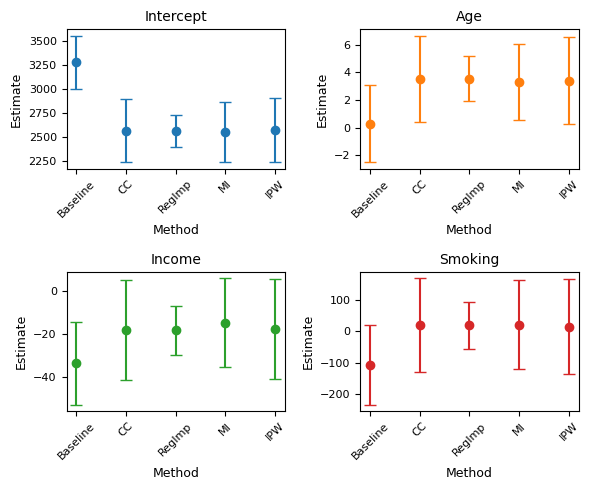


The confidence interval plots illustrate clear differences across estimation methods.
Regression imputation yields relatively narrow intervals, while multiple imputation and IPW produce wider intervals that reflect uncertainty due to missing data.
Overall, the intervals obtained under MI and IPW overlap substantially with those from complete-case analysis, but differ from the baseline model with no missing data.
